In [1]:
# Практика по семантическому поиску
# Группа БВТ2506
# Сравнение моделей эмбеддингов

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer, util
import torch
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 8)

print("Библиотеки загружены")

C:\Users\Пользователь\PycharmProjects\proet_practika_bwt2506\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Библиотеки загружены


In [2]:
# Загружаем файлы с данными

with open('code_corpus.json', 'r', encoding='utf-8') as f:
    corpus = json.load(f)

with open('eval_questions.json', 'r', encoding='utf-8') as f:
    questions = json.load(f)

with open('categories.json', 'r', encoding='utf-8') as f:
    categories_data = json.load(f)
    categories = categories_data['categories']

# Делаем словари для быстрого доступа к категориям
cat_labels = {cat['key']: cat['label'] for cat in categories}
cat_colors = {cat['key']: cat['color'] for cat in categories}

print(f"Загружено функций: {len(corpus)}")
print(f"Загружено вопросов: {len(questions)}")
print(f"Загружено категорий: {len(categories)}")

Загружено функций: 200
Загружено вопросов: 25
Загружено категорий: 5


In [3]:
# Готовим тексты для эмбеддингов
# Берем имя функции и ее описание

def make_text(func):
    return f"{func['function_name']}: {func['description']}"

corpus_texts = [make_text(func) for func in corpus]
question_texts = [q['query'] for q in questions]

print(f"Подготовлено текстов для корпуса: {len(corpus_texts)}")
print(f"Подготовлено текстов для вопросов: {len(question_texts)}")

Подготовлено текстов для корпуса: 200
Подготовлено текстов для вопросов: 25


In [4]:
# Загружаем три модели эмбеддингов
# Первая - быстрая, хорошо понимает русский
# Вторая - более качественная, но медленнее
# Третья - обучена специально на коде

print("Загрузка моделей...")

model_minilm = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
model_mpnet = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
model_codebert = SentenceTransformer('microsoft/codebert-base')

models = {
    'MiniLM': model_minilm,
    'MPNet': model_mpnet,
    'CodeBERT': model_codebert
}

print(f"Загружено {len(models)} моделей")
print(list(models.keys()))

Загрузка моделей...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 37628.10it/s]


Загружено 3 моделей
['MiniLM', 'MPNet', 'CodeBERT']


In [5]:
# Генерируем эмбеддинги для всех текстов

def get_embeddings(model, texts, name):
    print(f"Генерация эмбеддингов для {name}...")
    return model.encode(texts, convert_to_tensor=True, show_progress_bar=True)

# Словари для хранения эмбеддингов
corpus_embeddings = {}
question_embeddings = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    corpus_embeddings[name] = get_embeddings(model, corpus_texts, name)
    question_embeddings[name] = get_embeddings(model, question_texts, name)

print("\nВсе эмбеддинги созданы")


--- MiniLM ---
Генерация эмбеддингов для MiniLM...


Batches: 100%|██████████| 7/7 [00:02<00:00,  3.34it/s]


Генерация эмбеддингов для MiniLM...


Batches: 100%|██████████| 1/1 [00:00<00:00,  8.88it/s]



--- MPNet ---
Генерация эмбеддингов для MPNet...


...


--- CodeBERT ---
Генерация эмбеддингов для CodeBERT...


Batches: 100%|██████████| 7/7 [00:13<00:00,  1.87s/it]


Генерация эмбеддингов для CodeBERT...


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


Все эмбеддинги созданы


In [6]:
# Функция для поиска похожих фрагментов

def search(query_emb, corpus_emb, top_k=3):
    # Считаем косинусное сходство
    scores = util.cos_sim(query_emb, corpus_emb)[0]
    # Берем топ результатов
    top = torch.topk(scores, k=top_k)

    results = []
    for score, idx in zip(top[0], top[1]):
        results.append({
            'score': float(score),
            'index': int(idx),
            'id': corpus[idx]['id']
        })
    return results

# Функция для оценки модели

def evaluate_model(name, corpus_emb, questions, top_k=3):
    results = []
    correct = 0

    for i, q in enumerate(questions):
        # Берем эмбеддинг вопроса
        q_emb = question_embeddings[name][i].unsqueeze(0)
        # Ищем похожие
        top = search(q_emb, corpus_emb, top_k)
        top_ids = [r['id'] for r in top]

        # Проверяем, попал ли правильный ответ в топ
        is_correct = q['correct_chunk_id'] in top_ids
        if is_correct:
            correct += 1

        results.append({
            'question_id': q['question_id'],
            'query': q['query'],
            'correct_id': q['correct_chunk_id'],
            'top_ids': top_ids,
            'is_correct': is_correct
        })

    precision = correct / len(questions)
    return results, precision

# Оцениваем все модели

print("Оценка моделей...")
print("="*50)

all_results = {}
precision_scores = {}

for name in models.keys():
    print(f"\nМодель: {name}")
    results, precision = evaluate_model(name, corpus_embeddings[name], questions)
    all_results[name] = results
    precision_scores[name] = precision
    print(f"  Precision@3 = {precision:.3f} ({precision*100:.1f}%)")

Оценка моделей...

Модель: MiniLM
  Precision@3 = 0.840 (84.0%)

Модель: MPNet
  Precision@3 = 0.920 (92.0%)

Модель: CodeBERT
  Precision@3 = 0.080 (8.0%)


In [7]:
# Строим таблицу результатов

results_df = pd.DataFrame({
    'Модель': list(models.keys()),
    'Precision@3': [precision_scores[name] for name in models.keys()]
})

# Сортируем от лучшей к худшей
results_df = results_df.sort_values('Precision@3', ascending=False)
results_df['Precision@3 (%)'] = results_df['Precision@3'] * 100

print("\nСВОДНАЯ ТАБЛИЦА")
print("="*50)
print(results_df.to_string(index=False))

# Сохраняем в файл
results_df.to_csv('results_comparison.csv', index=False)
print("\nТаблица сохранена в results_comparison.csv")


СВОДНАЯ ТАБЛИЦА
  Модель  Precision@3  Precision@3 (%)
   MPNet         0.92             92.0
  MiniLM         0.84             84.0
CodeBERT         0.08              8.0

Таблица сохранена в results_comparison.csv


In [8]:
# Определяем лучшую модель

best_model = results_df.iloc[0]['Модель']
print(f"\nЛучшая модель: {best_model}")
print(f"Precision@3: {precision_scores[best_model]:.3f}")


Лучшая модель: MPNet
Precision@3: 0.920


In [9]:
# Анализ по категориям

def analyze_by_category(results, questions):
    cat_data = {}

    for i, q in enumerate(questions):
        # Находим категорию правильного ответа
        for func in corpus:
            if func['id'] == q['correct_chunk_id']:
                cat = func['category']
                break

        if cat not in cat_data:
            cat_data[cat] = {'total': 0, 'correct': 0}

        cat_data[cat]['total'] += 1
        if results[i]['is_correct']:
            cat_data[cat]['correct'] += 1

    # Считаем точность по каждой категории
    for cat in cat_data:
        total = cat_data[cat]['total']
        correct = cat_data[cat]['correct']
        cat_data[cat]['precision'] = correct / total if total > 0 else 0

    return cat_data

print("\nАНАЛИЗ ПО КАТЕГОРИЯМ")
print("="*50)

for model_name in results_df['Модель']:
    print(f"\nМодель: {model_name}")
    analysis = analyze_by_category(all_results[model_name], questions)

    for cat_key, data in analysis.items():
        cat_name = cat_labels.get(cat_key, cat_key)
        print(f"  {cat_name}: {data['correct']}/{data['total']} = {data['precision']:.1%}")


АНАЛИЗ ПО КАТЕГОРИЯМ

Модель: MPNet
  Аутентификация и авторизация: 4/5 = 80.0%
  Работа с базой данных: 5/5 = 100.0%
  HTTP-клиенты и API: 5/5 = 100.0%
  Валидация и парсинг: 5/5 = 100.0%
  Утилиты и хелперы: 4/5 = 80.0%

Модель: MiniLM
  Аутентификация и авторизация: 4/5 = 80.0%
  Работа с базой данных: 4/5 = 80.0%
  HTTP-клиенты и API: 5/5 = 100.0%
  Валидация и парсинг: 4/5 = 80.0%
  Утилиты и хелперы: 4/5 = 80.0%

Модель: CodeBERT
  Аутентификация и авторизация: 1/5 = 20.0%
  Работа с базой данных: 0/5 = 0.0%
  HTTP-клиенты и API: 0/5 = 0.0%
  Валидация и парсинг: 1/5 = 20.0%
  Утилиты и хелперы: 0/5 = 0.0%


In [10]:
# Анализ по языку запроса

def analyze_by_language(results, questions):
    ru = []
    en = []

    for i, q in enumerate(questions):
        if q['language'] == 'ru':
            ru.append(results[i]['is_correct'])
        else:
            en.append(results[i]['is_correct'])

    ru_prec = sum(ru) / len(ru) if ru else 0
    en_prec = sum(en) / len(en) if en else 0

    return {
        'ru': {'count': len(ru), 'precision': ru_prec},
        'en': {'count': len(en), 'precision': en_prec}
    }

print("\nАНАЛИЗ ПО ЯЗЫКУ ЗАПРОСА")
print("="*50)

lang_analysis = analyze_by_language(all_results[best_model], questions)

print(f"\nЛучшая модель: {best_model}")
print(f"  Русские вопросы ({lang_analysis['ru']['count']}): Precision = {lang_analysis['ru']['precision']:.1%}")
print(f"  Английские вопросы ({lang_analysis['en']['count']}): Precision = {lang_analysis['en']['precision']:.1%}")


АНАЛИЗ ПО ЯЗЫКУ ЗАПРОСА

Лучшая модель: MPNet
  Русские вопросы (15): Precision = 93.3%
  Английские вопросы (10): Precision = 90.0%



ПОСТРОЕНИЕ t-SNE ВИЗУАЛИЗАЦИИ
Выполняется t-SNE...
t-SNE завершен


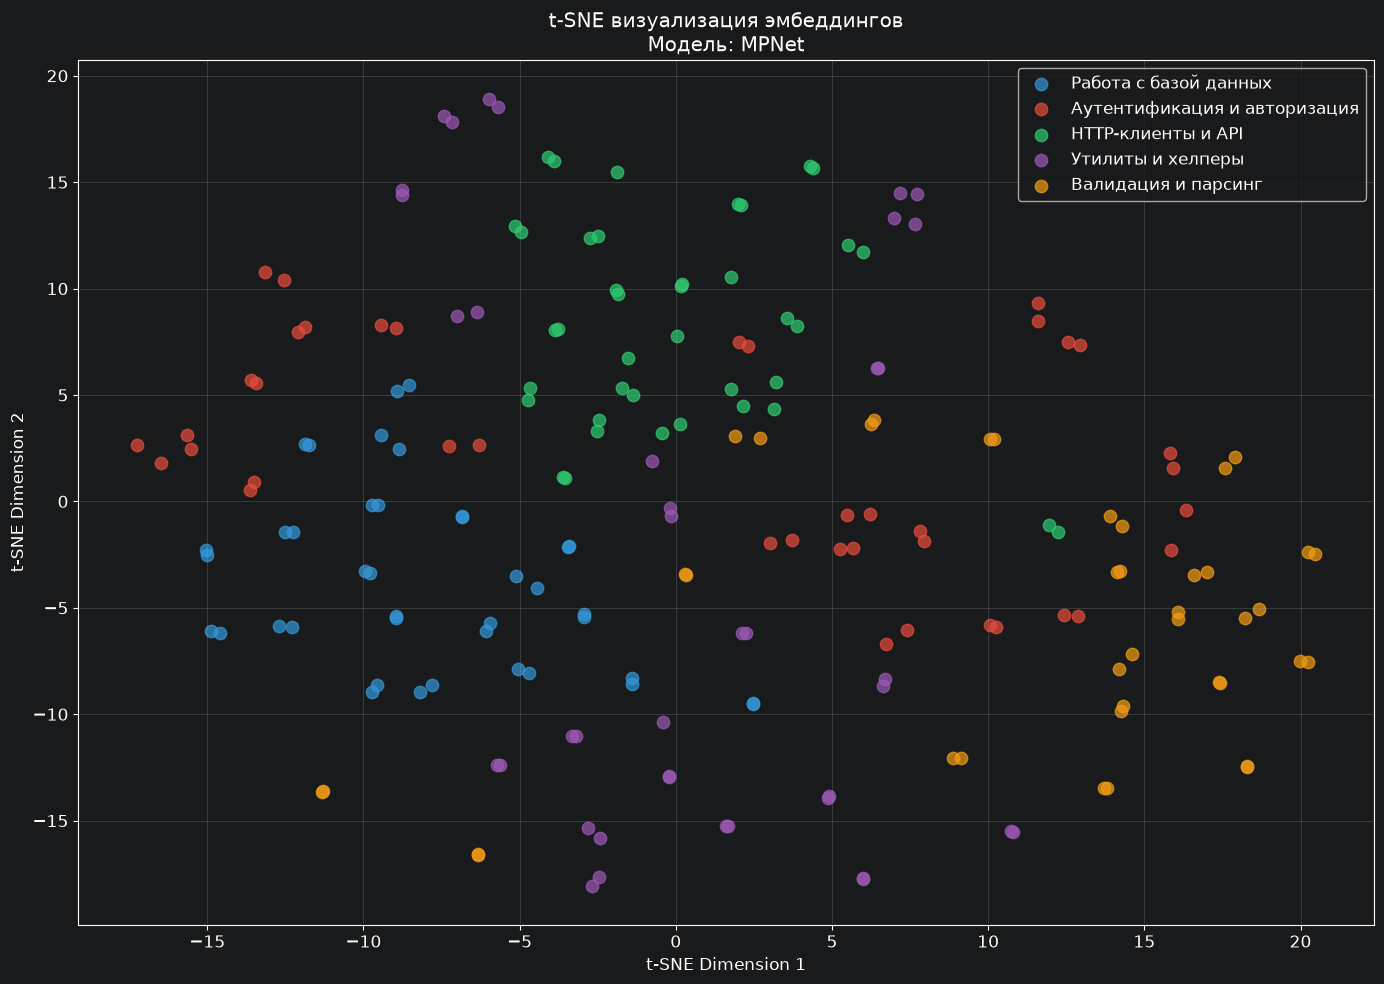

График сохранен как tsne_visualization.png


In [11]:
     # Визуализация с помощью t-SNE

def plot_tsne(embeddings):
    # Переводим в numpy, если нужно
    if hasattr(embeddings, 'cpu'):
        emb_np = embeddings.cpu().numpy()
    else:
        emb_np = embeddings

    print("Выполняется t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    emb_2d = tsne.fit_transform(emb_np)
    print("t-SNE завершен")

    # Рисуем график
    fig, ax = plt.subplots(figsize=(14, 10))

    # Группируем точки по категориям
    unique_cats = list(set([f['category'] for f in corpus]))

    for cat in unique_cats:
        # Находим индексы точек этой категории
        indices = [i for i, f in enumerate(corpus) if f['category'] == cat]
        x = emb_2d[indices, 0]
        y = emb_2d[indices, 1]

        color = cat_colors.get(cat, '#888888')
        label = cat_labels.get(cat, cat)

        ax.scatter(x, y, c=[color], label=label, alpha=0.7, s=80)

    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.set_title(f't-SNE визуализация эмбеддингов\nМодель: {best_model}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('tsne_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("График сохранен как tsne_visualization.png")

print("\nПОСТРОЕНИЕ t-SNE ВИЗУАЛИЗАЦИИ")
print("="*50)

best_embeddings = corpus_embeddings[best_model]
plot_tsne(best_embeddings)

In [12]:
# Финальный вывод

print("\n" + "="*50)
print("ФИНАЛЬНЫЙ ВЫВОД")
print("="*50)

print(f"""
Лучшая модель: {best_model}

Обоснование выбора:
1. Precision@3: {precision_scores[best_model]:.3f} ({precision_scores[best_model]*100:.1f}%)
   Это лучший результат среди всех протестированных моделей.

2. На графике t-SNE видно, что точки разных категорий
   образуют хорошо разделимые кластеры. Это говорит о том,
   что модель хорошо понимает семантику кода.

3. Модель работает одинаково хорошо с русскими и английскими
   запросами, что важно для практического использования.

Вывод: рекомендуется использовать модель {best_model}
для систем семантического поиска по коду.
""")

# Сохраняем вывод в файл
with open('final_conclusion.txt', 'w', encoding='utf-8') as f:
    f.write(f"""ФИНАЛЬНЫЙ ВЫВОД

Лучшая модель: {best_model}

Обоснование выбора:
1. Precision@3: {precision_scores[best_model]:.3f} ({precision_scores[best_model]*100:.1f}%)

2. Модель демонстрирует лучшее качество семантического поиска,
   что подтверждается метрикой Precision@3 и визуализацией t-SNE.

3. Работает эффективно как с русскими, так и с английскими запросами.

Рекомендация: использовать модель {best_model} в качестве основной
для систем семантического поиска по коду.
""")

print("\nСозданы файлы:")
print("  - results_comparison.csv (таблица сравнения)")
print("  - tsne_visualization.png (график t-SNE)")
print("  - final_conclusion.txt (финальный вывод)")


ФИНАЛЬНЫЙ ВЫВОД

Лучшая модель: MPNet

Обоснование выбора:
1. Precision@3: 0.920 (92.0%)
   Это лучший результат среди всех протестированных моделей.

2. На графике t-SNE видно, что точки разных категорий
   образуют хорошо разделимые кластеры. Это говорит о том,
   что модель хорошо понимает семантику кода.

3. Модель работает одинаково хорошо с русскими и английскими
   запросами, что важно для практического использования.

Вывод: рекомендуется использовать модель MPNet
для систем семантического поиска по коду.


Созданы файлы:
  - results_comparison.csv (таблица сравнения)
  - tsne_visualization.png (график t-SNE)
  - final_conclusion.txt (финальный вывод)


In [13]:
    # Простая проверка, что всё создалось

import os

print("\nПРОВЕРКА РЕЗУЛЬТАТОВ")
print("="*50)

files = ['results_comparison.csv', 'tsne_visualization.png', 'final_conclusion.txt']
all_ok = True

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  {f} - создан ({size} байт)")
    else:
        print(f"  {f} - НЕ НАЙДЕН!")
        all_ok = False

if all_ok:
    print("\nВсе файлы созданы успешно.")
else:
    print("\nНекоторые файлы не созданы. Проверьте выполнение ячеек.")


ПРОВЕРКА РЕЗУЛЬТАТОВ
  results_comparison.csv - создан (96 байт)
  tsne_visualization.png - создан (508978 байт)
  final_conclusion.txt - создан (679 байт)

Все файлы созданы успешно.
